# Homework 4: Part 2 and 3 (Simulating and interpreting differential equations)


### ANSWER

General notes:

Compartmental models and solve_ivp are historically challenging concepts for students in CMSE 201. **Therefore, even for assessments like Quizzes and Homework, substantial scaffolding should be provided** (whether that be several smaller questions, starter code, having equations given, etc.). Separating the different components of compartmental modeling and solve_ivp into questions that are not dependent on one another can also decrease instances of a student getting stuck on one question and not being able to progress to the rest of the assignment.

The component of data visualization should be (mostly) separated from solve_ivp because we want to focus to be on assessing the quality of their visualizations, rather than the model creating them. Therefore, the data should be relatively clean, and the rubric based on the components of a good visualization (See Day 20).

Proposed Structure:

* Part 0: Academic Integrity statement

 *(solve_ivp related questions can occur in any order and should be independent as much as possible)*
 
* Part 1: Problem to assess writing equations from a compartmental model (and some free response questions to proble understanding)
* Part 2: Given functioning starter code for a model, make some sort of change, run solve_ivp, plot and interpret the results
* Part 3: Interpreting results of a compartmental model (provide a model description and output, ask students to interpret the results - scaffolding is important here!)
* Part 4: Data Visualization assessment - Given a data set, create a plot, self-critique it based on the rubric for a good visualization, update the visualization based on your self-critique. 
* Part 5: Given a plot of data (with data context provided), provide evidence for a claim you can make about the data.

**NOTE: You should also periodically ask Metacognition questions throughout the assignment to probe understanding!**

# Example

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, April 18th, 2025** 

It should be uploaded into D2L Homework #4.  Submission instructions can be found at the end of the notebook.

---
<a id="toc"></a>

## Table of Contents


[Part 2. Simulating differential equations](#part_2)  (20 points)

[Part 3. Interpreting results of simulations](#part_3) (15 points)




<a id="part_2"></a>
## Part 2. Solving differential equations numerically (20 total points)

[Back to Top](#toc)

In previous assignments, you have used `solve_ivp` to compute the numeric solution of the logistic model of the growth of a single population. Recall, the Logistic population model is described by the following differential equations:

\begin{equation}
\frac{dP}{dt} = kP\Big(1-\frac{P}{C}\Big),
\end{equation}

where $P =$ population, $k =$ growth rate, and $C =$ the carrying capacity. 

Examples code for computing the solution for for $P_0 =0.1$ billion (initial population), $k=1$, and $C =1$ billion is provided below:

In [7]:
# example code to compute a numeric solution of the logistic model
import numpy as np
from scipy.integrate import solve_ivp

# define the derivative
def logistic(time, current_state):
    p = current_state   
    dpdt = p*(1-p)    
    return dpdt

# compute numeric solution
initial_p = [0.1]
time = np.linspace(0,10,50)

result = solve_ivp(logistic, (0,20), initial_p, t_eval = time)

# unpack solution
numerical_p = result.y[0,:]

## Cyclic 3-Species (Rock–Paper–Scissors) Ecosystem Model

Now you wonder: what happens if **three different species interact in a cyclic way** — each one outcompetes a second, the second outcompetes a third, and the third outcompetes the first. 
(This is the ecological analogue of **Rock–Paper–Scissors (RPS)**.)

Such cyclic systems are common in nature (for example, among certain bacterial strains or lizard morphs) and can produce rich dynamics including **coexistence**, **oscillations**, and **heteroclinic cycles**.

A simple nondimensional model for three interacting species \(u(t)\), \(v(t)\), and \(w(t)\) is:

\begin{align}
\frac{du}{dt} &=u(1-u-av)  &(1)\\
\frac{dv}{dt} &=v(1-v-bw)  &(2)\\
\frac{dw}{dt} &=w(1-w-cu).  &(3)
\end{align}



Solve this RPS system using `solve_ivp`. Assuming $a = b= c =2$, and the following initial conditions:

* $u(0) = 0.6$
* $v(0) = 0.2$
* $w(0) = 0.5$ in units of thousands.

Evolve the model for 40 decades (400 years) using a timestep of $\Delta t = 0.01$ decades.

---

### Notes
- Each species grows logistically when alone (carrying capacity scaled to 1).  
- Cross terms such as \(a v\) represent harmful competition from another species.  
- When \(a=b=c\), the system is **symmetric**; when the parameters differ, **asymmetry** can lead to new behaviors.

---

### Biological Example
Three bacterial strains (A, B, C) compete for the same nutrient:
- A produces a compound that inhibits C,  
- C inhibits B,  
- B inhibits A.  
This forms a **cyclic dominance network** similar to Rock–Paper–Scissors.

---

### Your Task

Implement and analyze the three-species cyclic Lotka–Volterra model above.  
You can adapt your code from the logistic model.

&#9989;&nbsp; **Part 2.1 (8 points)**  
Define the derivative function for the three-species competitive Lotka-Volterra model in the cell below (to be used as an input later for `solve_ivp` -- so pay attention to the format).

In [8]:
# write your function here
# example code to compute a numeric solution of the logistic model


In [11]:
### ANSWER
# Define the derivatives function
def derivs(t, vals,a,b,c):
    u, v, w = vals
    dudt = u*(1- u - a*v)
    dvdt = v*(1- v- b*w)
    dwdt = w*(1- w- c*u)
    return dudt, dvdt, dwdt
    
## rubric
# 2 pts for any attempt at defining a function
# 2 pts for getting input argument positions correct
# 1 pt for unpacking current_state correctly
# 1 pt for returning du dv correctly
# 2 pts for defining the equations correctly

&#9989;&nbsp; **Part 2.2 (6 points)**

Using `solve_ivp`, compute the numeric solution for RPS model with the parameters $a=2.0$, $b=2.0,$ $c=2.0$, the initial conditions $[u_0,v_0,w_0]= [0.6,0.2,0.5]$, and the final time equal 40. Unpack the result you get from `solve_ivp` into separate variables `u`,`v`,and `w`.

In [12]:
# put your code here


In [13]:
### ANSWER
# Solve the system
a = 2.0
b = 2.0
c = 2.0

args = (a,b,c)
u0 = 0.6
v0 = 0.2
w0 = 0.5
ICs = [u0, v0, w0]
t = np.arange(0, 40, 0.01)
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t,args=args)
u = sol.y[0,:]
v = sol.y[1,:]
w = sol.y[2,:]

## Rubric
# 2 pts for defining parameters and initial conditions correctly
# 1 pt for defining time array
# 2 pts for calling solve_ivp correctly
# 1 pt for unpacking the results

&#9989;&nbsp; **Part 2.3 (4 points)**

Plot the solutions of $u$, $v$, and $w$ as a function of time in the cell below. Be sure to add appropriate axis labels and legends. 

In [14]:
# put our code here


Text(0.5, 1.0, 'Solution of the RPS system')

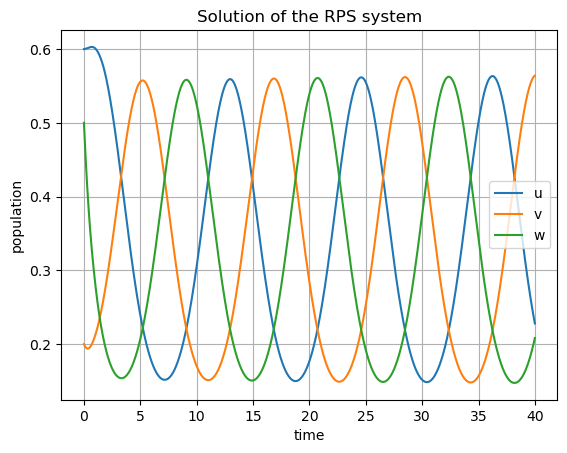

In [15]:
### ANSWER
import matplotlib.pyplot as plt

plt.plot(t, u, label='u')
plt.plot(t, v, label='v')
plt.plot(t, w, label='w')
plt.grid()
plt.legend()
plt.xlabel('time')
plt.ylabel('population')
plt.title('Solution of the RPS system')

#plt.savefig('RPS-a2b2c2.png') 
## Rubric
# 2 pts for plotting the three lines correctly
# 2 pts for axis labels and legends

&#9989;&nbsp; **Part 2.4 (2 points)**

When $a=b=c$, we call the model a symmetric model. Check with the plot above to see what will happen as time goes on. Can the three species, i.e. $u$, $v$, and $w$, coexist or one species will die out?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### ANSWER
The three species will coexist together. (2 points)

<a id="part_3"></a>
## Part 3. Interpreting model behavior for different parameters and initial conditions  (15 total points)

In Part 2, you have explored the three species competitive Lotka-Volterra model in a symmetric scenario, i.e. neither species were very competitive with parameters $a$, $b$ and $c$ where $a=b=c$. 

In this part, you will be shown the solutions of the model under a couple of different asymmetric competition scenarios and with the initial condition. You will be asked to interpret these plots.

&#9989;&nbsp; **Part 3.1 (5 points)** Asymmetric competition case ($a<b=c$)

The figure below shows the  numerically solved population growth dynamics of the three species $u$, $v$ and $w$:

![RPS-a1b2c2.png](RPS-a1b2c2.png)


The initial population was $u_0 = 0.6$, $v_0 =0.2$, and $w_0 = 0.5$. The parameters were $a = 1$, $b=c=2$. In the cell below, answer the following questions:

1. Based on the plot, which species was more successful at the beginning? which species was more successful at the end? Here success is measured by population size. 

2. Based on the plot, which species was more competitive?

3. Connecting your visual interpretations to the model parameters $a, b,$ and $c$, explain how these three parameters determine which species is strongly competitive and which species is weakly competitive.

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### ANSWER

1. u was more successful at the beginning, v was more successful at the end (2 pts)
2. v was more competitive (1 pts)
3. $a $ determines $v$ to be strongly competitive, $b$ and initial $w_0$ determines $w$ to be weakly competitive. (2 pts)

&#9989;&nbsp; **Part 3.2 (4 points)** Asymmetric competition case ($b <a=c$)

Now we changed the parameters so that $a=c=2$ and $b =1$, with initial conditions remain the same. We obtained the following figure:

![RPS-a2b1c2.png](RPS-a2b1c2.png)

In the cell below, answer the following questions:
1. How is this figure different from the one in Part 3.1?
2. How are the changes in parameters $a,b$ and $c$ related to changes in the figure?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### ANSWER

1. now $w$ wins (2 pts)
2. now $w$ becomes more competitive while $b<a=c$. (2 pts)

&#9989;&nbsp; **Part 3.3 (6 points)** Asymmetric competition case ($c<a=b$)

We changed the parameters again to be $a=b=2$ and $c =1$,with initial conditions remain the same ($[u_0,v_0,w_0] = [0.6,0.2,0.5]$). We obtained the following figure:

![RPS-a2b2c1.png](RPS-a2b2c1.png)

Then, we use a different set of parameters with $a = 2.0, b=1.5$, and $c=1.0$ while the initial population levels still be the same ($[u_0,v_0,w_0] = [0.6,0.2,0.5]$). We obtained the figure below:

![RPS-a2b2c1.png](RPS-a2b15c1.png)

Compare the two figures, and answer the following questions in the cell below:

1. In what aspects are these two figures different in terms of the final outcome? 

2. What differences in the model caused the differences in the figures?

3. Why would the short term dynamics of the two figures look different, especially we still keep the competitive parameter $c < b < a$?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### ANSWER

1. In the first plot, species $w$ was the most successful. In the second plot, both species 
$w$ and $u$ were equally successful, reaching the same population level. (2 pts)
2. The competitive parameters are different (2 pts)
3. $u$ is strongly suppressed by $v$, but $v$ itself is weakened by $w$ As a result, the net effects on $u$ and $w$ become comparable, leading them to stabilize at similar long-term equilibrium densities. (2 pts)

## Congratulations, you're done!

Submit this assignment by uploading your notebook to the course Desire2Learn web page.  Go to the "Homework" folder, find the appropriate submission link, and upload everything there. Make sure your name is on it!

&#169; Copyright 2025,  Department of Computational Mathematics, Science and Engineering at Michigan State University